# Reaching test — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)  
**Figures:** Figure 7E–N, Supplementary Figure 15

This notebook demonstrates how to access each data stream in the reaching-test NWB files produced by
`src/meletis_lab_to_nwb/reaching_test/convert_session.py`.

## About the experiment

Water-restricted mice reach through a slit to a pump-controlled waterspout. Each reach attempt is
recorded laterally at 60 fps (FLIR camera). Two experimental arms are represented in the dataset:

- **`tet` / `ctrl`** — chronic silencing of Anxa1+ SNc dopamine neurons via Flp-dependent
  tetanus toxin light chain, against littermate controls.
- **`arch_anxa1` / `arch_ctrl`** — optogenetic silencing of Anxa1+ SNc dopamine neurons with
  Archaerhodopsin, against littermate controls. Sessions have a `light` column
  (`on`, `on_after_first_reach`, `off`) capturing whether silencing was active.

Each mouse performs the reaching task on multiple test days (`phase`: `test1`, `test2`,
`test4`, `test8`). Some mice performed no attempts on some sessions — those NWB files simply
have no `reaching_events` table but still carry video + DeepLabCut pose estimation.

## Data streams per NWB file

| Stream | NWB location | Description |
|--------|--------------|-------------|
| **Behavior video** | `acquisition/BehaviorVideo` | Lateral-view reaching video, stored by external reference (not copied into the NWB file) |
| **Pose estimation** | `processing/behavior/PoseEstimationReaching` | DeepLabCut tracking for 8 keypoints: `snout`, `tongue`, `palm`, `wrist`, `elbow`, `mouth`, `spout`, `extra` |
| **Skeleton** | `processing/behavior/Skeletons` | Skeleton node definition (linked to the subject) |
| **Reach annotations** | `processing/behavior/reaching_events` | Manually-scored reach attempts, stored as an ndx-events `AnnotatedEventsTable` (one row per event type, ragged `event_times` + ragged per-event metadata). Absent when the mouse performed no attempts |

## Setup

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pynwb import read_nwb

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Load NWB file

Point the path below at any reaching-test NWB produced by the pipeline. This demo uses a
session from subject `714028` (Anxa1-Flp, `tet` cohort) on test day 1, which has all three
streams populated.

In [31]:
nwb_path = Path(
    "/Users/weian/catalystneuro/meletis-lab-to-nwb/nwb_output/reaching_test/"
    "sub-714028/sub-714028_ses-reaching-test-2023-11-10T10-03-20_behavior+image.nwb"
)

nwbfile = read_nwb(nwb_path)

print(f"Session ID:         {nwbfile.session_id}")
print(f"Session start:      {nwbfile.session_start_time}")
print(f"Institution / lab:  {nwbfile.institution} / {nwbfile.lab}")
print(f"Related pubs:       {nwbfile.related_publications}")
print("----")
print(f"Subject ID:         {nwbfile.subject.subject_id}")
print(f"Species / strain:   {nwbfile.subject.species} / {nwbfile.subject.strain}")
print(f"Genotype:           {nwbfile.subject.genotype}")
print(f"Sex:                {nwbfile.subject.sex}")
print(f"Date of birth:      {nwbfile.subject.date_of_birth}")
print("----")
print("Session description:")
print(nwbfile.session_description)

Session ID:         reaching-test-2023-11-10T10-03-20
Session start:      2023-11-10 10:03:20+01:00
Institution / lab:  Karolinska Institutet / Meletis
Related pubs:       ('doi:10.1101/2024.12.22.629963',)
----
Subject ID:         714028
Species / strain:   Mus musculus / C57BL/6N
Genotype:           Anxa1-flp
Sex:                F
Date of birth:      2023-04-20 00:00:00+02:00
----
Session description:
Forelimb reaching-for-water session. The lateral behavior video is referenced
externally and accompanied by manual reach-attempt annotations (when the mouse
performed any attempts) and DeepLabCut pose-estimation traces. Per-session cohort
(`group`, `line`), test-day phase, and Arch light condition are exposed in the
session metadata.

Experiment: reaching_test_anxa1_tet. Anxa1+ SNc dopamine neurons chronically silenced via Flp-dependent tetanus toxin light chain in Anxa1-Flp mice (tet cohort). Virus: AAV9-hSyn1-chl-dFRT-EGFP_2A_Flag_TeTxLC(rev)-dFRT (VVF Zurich), 300 nL bilateral SNc in

## NWB file structure overview

In [38]:
print("=== Acquisition ===")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Processing ===")
for mod_name, mod in nwbfile.processing.items():
    print(f"  {mod_name}: {mod.description if mod.description else ''}")
    for name, obj in mod.data_interfaces.items():
        extra = ""
        if type(obj).__name__ == "AnnotatedEventsTable":
            n_types = len(obj)
            n_events = sum(len(obj["event_times"][i]) for i in range(n_types))
            extra = f" ({n_types} event types, {n_events} events)"
        print(f"    {name}: {type(obj).__name__}{extra}")

if len(nwbfile.intervals):
    print("\n=== Intervals ===")
    for name, obj in nwbfile.intervals.items():
        df_iv = obj.to_dataframe()
        print(f"  {name}: {type(obj).__name__} ({len(df_iv)} rows)")

print("\n=== Devices ===")
for name, obj in nwbfile.devices.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Subject ===")
s = nwbfile.subject
print(f"  subject_id:  {s.subject_id}")
print(f"  species:     {s.species}")
print(f"  genotype:    {s.genotype}")
print(f"  strain:      {s.strain}")
print(f"  sex:         {s.sex}")
print(f"  DoB:         {s.date_of_birth}")

=== Acquisition ===
  Video reaching_test_2023-11-10T10_03_20: ImageSeries

=== Processing ===
  behavior: processed behavioral data
    PoseEstimationReaching: PoseEstimation
    Skeletons: Skeletons
    reaching_events: AnnotatedEventsTable (5 event types, 128 events)

=== Devices ===
  FLIR Camera: Device

=== Subject ===
  subject_id:  714028
  species:     Mus musculus
  genotype:    Anxa1-flp
  strain:      C57BL/6N
  sex:         F
  DoB:         2023-04-20 00:00:00+02:00


## 1. Behavior video (external reference)

The lateral behavior video is stored by external reference (not copied into the NWB file).
Grab the path from `acquisition/BehaviorVideo`.

In [32]:
from pynwb.image import ImageSeries

video_keys = [k for k, v in nwbfile.acquisition.items() if isinstance(v, ImageSeries)]
bv = nwbfile.acquisition[video_keys[0]]
print(f"Video name:       {bv.name}")
print(f"External files:   {list(bv.external_file[:])}")
print(f"Starting frame:   {bv.starting_frame[:] if bv.starting_frame is not None else 0}")
print(f"Description:      {bv.description}")

Video name:       Video reaching_test_2023-11-10T10_03_20
External files:   ['/Volumes/T9/data/Meletis/reaching_test/videos/reaching_test_2023-11-10T10_03_20.avi']
Starting frame:   [0]
Description:      Video recorded by camera.


## 2. Reach annotations

Manually-scored reach attempts live at `processing/behavior/reaching_events` as an
ndx-events `AnnotatedEventsTable`. Each **row** of that table is one event **type**
(`correct`, `miss`, `empty`, `drop`, `semidrop`, or `unknown`); each row carries a
ragged `event_times` column plus ragged per-event metadata columns. Event times are in
seconds relative to `session_start_time` (computed as `frame_index / 60 Hz`).

| Column | Meaning |
|--------|---------|
| `label` | Event type (row identifier). |
| `event_description` | Human-readable description of the event type. |
| `event_times` | Ragged list of onset times (seconds from session start) for all events of this type. |
| `paw` | Body part contacting the spout for each event: `left`, `right`, `mouth`, or `unknown`. |
| `frame` | Annotated video frame index (0-based) for each event. |
| `target_x`, `target_y` | Spout position in video pixels for each event. |
| `paw_x`, `paw_y` | Paw position in video pixels at each event. |
| `reference_px` | Pixel reference distance used for pixel→cm conversion, per event. |
| `distance_px`, `distance_cm` | Reach distance to spout in pixels / cm, per event. |

Sessions where the mouse performed no attempts have no `reaching_events` table at all.
The cell below handles both cases and **flattens** the ragged `AnnotatedEventsTable` into
a long one-row-per-event DataFrame (`reach_df`) for convenience in downstream plots.

In [33]:
import pandas as pd


def _flatten_reaching_events(events_table) -> pd.DataFrame:
    """Flatten an AnnotatedEventsTable into a long one-row-per-event DataFrame.

    Each input row corresponds to one event type with ragged `event_times` and ragged
    per-event metadata columns. We expand these into one row per event instance with
    scalar columns, sorted chronologically. Column names match the per-event metadata
    plus an `event_time` (seconds since session start) and `event_type` (row label).
    """
    df_types = events_table.to_dataframe()
    metadata_cols = [
        c for c in df_types.columns
        if c not in ("event_times", "label", "event_description")
    ]
    records = []
    for _, row in df_types.iterrows():
        event_times = list(row["event_times"])
        n = len(event_times)
        for i in range(n):
            rec = {"event_type": row["label"], "event_time": float(event_times[i])}
            for col in metadata_cols:
                rec[col] = row[col][i]
            records.append(rec)
    out = pd.DataFrame.from_records(records)
    if len(out):
        out = out.sort_values("event_time").reset_index(drop=True)
    return out


reach_table = None
reach_df = None
if "behavior" in nwbfile.processing and "reaching_events" in nwbfile.processing["behavior"].data_interfaces:
    reach_table = nwbfile.processing["behavior"]["reaching_events"]

if reach_table is not None:
    print(f"AnnotatedEventsTable: {type(reach_table).__name__}")
    print(f"Event types (rows):   {list(reach_table['label'][:])}")
    per_type_counts = {
        str(lbl): len(reach_table["event_times"][i])
        for i, lbl in enumerate(reach_table["label"][:])
    }
    print(f"Events per type:      {per_type_counts}")

    reach_df = _flatten_reaching_events(reach_table)
    print(f"\nTotal reach attempts: {len(reach_df)}")
    print(f"Event-type counts:    {reach_df['event_type'].value_counts().to_dict()}")
    print(f"Paw counts:           {reach_df['paw'].value_counts().to_dict()}")
    print("\nFirst 10 events:")
    display_df = reach_df.head(10)
else:
    display_df = None
    print("This session has no reaching_events table (the mouse performed no attempts).")
display_df

AnnotatedEventsTable: AnnotatedEventsTable
Event types (rows):   ['correct', 'drop', 'empty', 'miss', 'semidrop']
Events per type:      {'correct': 34, 'drop': 10, 'empty': 36, 'miss': 42, 'semidrop': 6}

Total reach attempts: 128
Event-type counts:    {'miss': 42, 'empty': 36, 'correct': 34, 'drop': 10, 'semidrop': 6}
Paw counts:           {'left': 121, 'right': 7}

First 10 events:


,event_type,event_time,frame,paw,target_x,target_y,paw_x,paw_y,reference_px,distance_px,distance_cm
0,miss,178.133333,10688,left,-177.31,-96.18,-166.57,4.84,227.49,101.589310,0.446566
1,miss,180.333333,10820,left,-177.31,-96.18,-181.22,24.08,227.49,120.323546,0.528918
2,miss,183.950000,11037,right,-177.31,-96.18,-163.34,-17.73,227.49,79.684148,0.350275
3,miss,188.350000,11301,right,-177.31,-96.18,-151.84,67.62,227.49,165.768395,0.728684
4,correct,194.766667,11686,left,-177.31,-96.18,-180.14,-84.76,227.49,11.765428,0.051718
5,correct,252.050000,15123,left,-177.31,-96.18,-152.93,-117.42,227.49,32.334533,0.142136
6,drop,260.016667,15601,left,-177.31,-96.18,-161.63,-55.37,227.49,43.718629,0.192178
7,miss,261.533333,15692,left,-177.31,-96.18,-113.74,-146.80,227.49,81.262102,0.357212
8,miss,261.883333,15713,left,-177.31,-96.18,-162.72,-61.90,227.49,37.255691,0.163768
9,miss,262.583333,15755,left,-177.31,-96.18,-188.84,-220.82,227.49,125.172163,0.550231


### Reach event raster

One subplot per event type shows when each event occurred across the session as tick marks.
Subplots share the time axis so temporal density is directly comparable across outcomes.

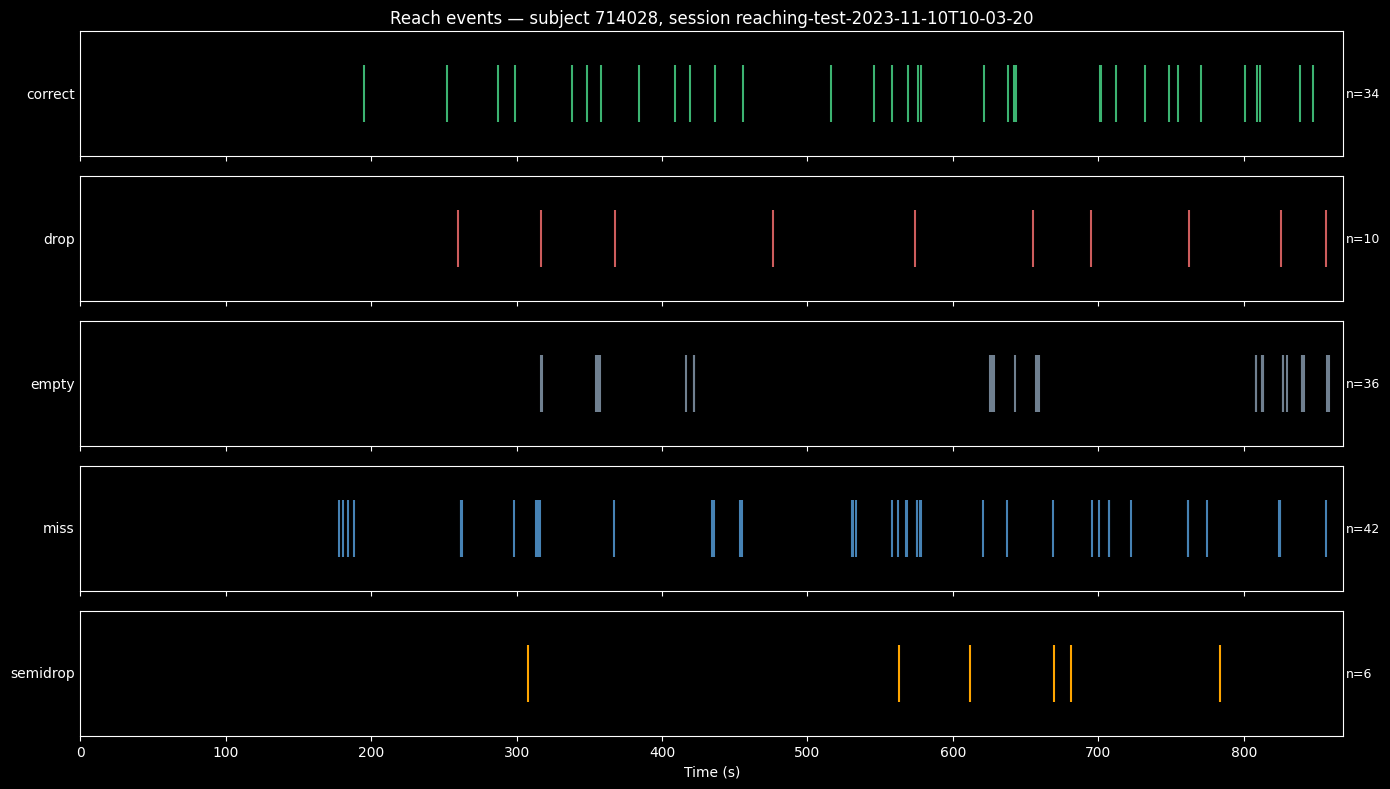

In [34]:
if reach_df is not None and len(reach_df):
    _palette = {
        "correct": "mediumseagreen",
        "miss": "steelblue",
        "empty": "slategray",
        "drop": "indianred",
        "semidrop": "orange",
        "unknown": "black",
    }
    event_types = list(reach_table["label"][:])
    n_types = len(event_types)

    fig, axes = plt.subplots(
        n_types, 1,
        figsize=(14, max(2.0, 1.6 * n_types)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    t_max = reach_df["event_time"].max()

    for i, event_type in enumerate(event_types):
        ax = axes[i, 0]
        sub = reach_df[reach_df["event_type"] == event_type]
        times = sub["event_time"].values
        color = _palette.get(event_type, "black")
        ax.eventplot(times, orientation="horizontal", colors=color, linewidths=1.5, linelengths=0.6)
        ax.set_ylabel(event_type, rotation=0, ha="right", va="center", fontsize=10)
        ax.set_yticks([])
        ax.annotate(
            f"n={len(times)}",
            xy=(1.002, 0.5), xycoords="axes fraction",
            ha="left", va="center", fontsize=9,
        )
        ax.set_xlim(0, t_max + 10)

    axes[-1, 0].set_xlabel("Time (s)")
    axes[0, 0].set_title(
        f"Reach events — subject {nwbfile.subject.subject_id}, session {nwbfile.session_id}"
    )
    fig.tight_layout()
    plt.show()
else:
    print("No reach events found in this file.")

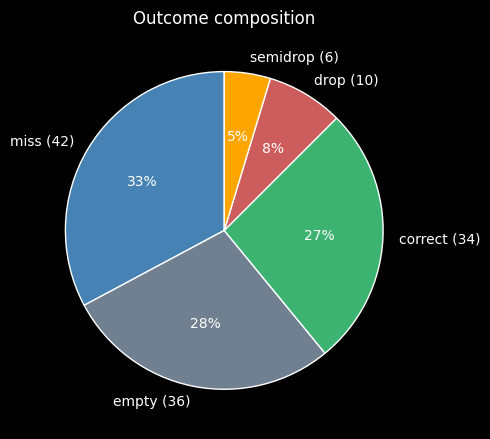

In [35]:
if reach_df is not None and len(reach_df):
    palette = {
        "correct": "mediumseagreen",
        "miss": "steelblue",
        "empty": "slategray",
        "drop": "indianred",
        "semidrop": "orange",
        "unknown": "black",
    }

    vc = reach_df["event_type"].value_counts()
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(
        vc.values,
        labels=[f"{k} ({v})" for k, v in vc.items()],
        colors=[palette.get(k, "black") for k in vc.index],
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops=dict(edgecolor="white"),
    )
    ax.set_title("Outcome composition")
    plt.tight_layout()
    plt.show()
else:
    print("No events to visualize.")

## 3. DeepLabCut pose estimation

The `PoseEstimationReaching` container holds one `PoseEstimationSeries` per tracked keypoint.
Each series has `data` of shape `(n_frames, 2)` (x, y in pixels) and a `confidence` array with
the DLC likelihood score per frame. A `Skeletons` object alongside it records the node names.

In [36]:
pose = nwbfile.processing["behavior"]["PoseEstimationReaching"]
print(f"Name:              {pose.name}")
print(f"Scorer:            {pose.scorer}")
print(f"Source software:   {pose.source_software}")
print(f"Description head:  {pose.description[:200]!s}…")
print(f"Keypoints ({len(pose.pose_estimation_series)}):")
for name, series in pose.pose_estimation_series.items():
    print(f"  {name:32s}  data {series.data.shape}  confidence {series.confidence.shape}")

skel_container = nwbfile.processing["behavior"]["Skeletons"]
print("\nSkeleton(s):")
for name, s in skel_container.skeletons.items():
    print(f"  {name}  nodes={list(s.nodes[:])}")

Name:              PoseEstimationReaching
Scorer:            DLC_resnet50_reaching_trainJun9shuffle1_100000
Source software:   DeepLabCut
Description head:  DeepLabCut pose estimation for the forelimb reaching test. Eight keypoints were
tracked on the lateral behavior video: snout, tongue, palm, wrist, elbow, mouth
(reach target reference on the animal), …
Keypoints (8):
  PoseEstimationSeriesElbow         data (55136, 2)  confidence (55136,)
  PoseEstimationSeriesExtra         data (55136, 2)  confidence (55136,)
  PoseEstimationSeriesMouth         data (55136, 2)  confidence (55136,)
  PoseEstimationSeriesPalm          data (55136, 2)  confidence (55136,)
  PoseEstimationSeriesSnout         data (55136, 2)  confidence (55136,)
  PoseEstimationSeriesSpout         data (55136, 2)  confidence (55136,)
  PoseEstimationSeriesTongue        data (55136, 2)  confidence (55136,)
  PoseEstimationSeriesWrist         data (55136, 2)  confidence (55136,)

Skeleton(s):
  SkeletonPoseEstimationDeep

### DLC keypoint trajectories across the session

Palm trajectory colored by time gives a spatial overview of reaching behavior across the
full session. The confidence histogram shows DLC tracking quality for key keypoints; the
x/y time series below details the first 60 s of palm, wrist, and spout positions.

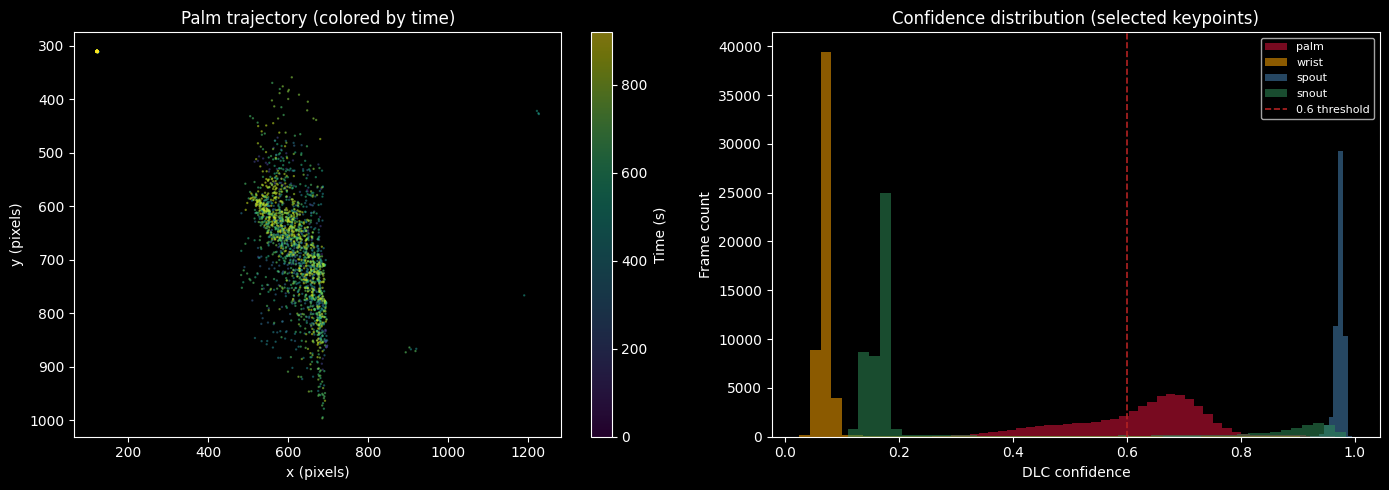

In [37]:
palm = pose.pose_estimation_series["PoseEstimationSeriesPalm"]
palm_xy = np.asarray(palm.data[:])
palm_conf = np.asarray(palm.confidence[:])
if palm.timestamps is not None:
    t_palm = np.asarray(palm.timestamps[:])
else:
    t_palm = (palm.starting_time or 0.0) + np.arange(len(palm_xy)) / float(palm.rate)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palm trajectory colored by time
ax = axes[0]
sc = ax.scatter(palm_xy[:, 0], palm_xy[:, 1], c=t_palm, s=0.5, cmap="viridis", alpha=0.5)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Palm trajectory (colored by time)")
ax.invert_yaxis()
plt.colorbar(sc, ax=ax, label="Time (s)")

# Confidence distribution for key keypoints
kp_styles = [
    ("PoseEstimationSeriesPalm", "crimson", "palm"),
    ("PoseEstimationSeriesWrist", "orange", "wrist"),
    ("PoseEstimationSeriesSpout", "steelblue", "spout"),
    ("PoseEstimationSeriesSnout", "seagreen", "snout"),
]
ax = axes[1]
for kp_name, color, label in kp_styles:
    conf = np.asarray(pose.pose_estimation_series[kp_name].confidence[:])
    ax.hist(conf, bins=50, alpha=0.55, label=label, color=color, edgecolor="none")
ax.axvline(0.6, color="firebrick", linestyle="--", linewidth=1.2, label="0.6 threshold")
ax.set_xlabel("DLC confidence")
ax.set_ylabel("Frame count")
ax.set_title("Confidence distribution (selected keypoints)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()